# 5.2 分类任务：威斯康星乳腺癌数据集

逻辑回归二分类；准确率；混淆矩阵。

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 1. 数据加载

In [3]:
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
cancer_df["TARGET"] = cancer.target

print("数据集形状：", cancer_df.shape)
print("缺失值总数：", cancer_df.isnull().sum().sum())
print(
    "肿瘤类型分布：\n",
    cancer_df["TARGET"].value_counts().rename({0: "恶性", 1: "良性"}),
)

X_c = cancer_df.drop("TARGET", axis=1)
y_c = cancer_df["TARGET"]

数据集形状： (569, 31)
缺失值总数： 0
肿瘤类型分布：
 TARGET
良性    357
恶性    212
Name: count, dtype: int64


## 2. 预处理与划分

In [4]:
scaler_c = StandardScaler()
X_c_scaled = scaler_c.fit_transform(X_c)

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c_scaled, y_c, test_size=0.3, random_state=42
)
print("训练集样本数：", X_c_train.shape[0])
print("测试集样本数：", X_c_test.shape[0])

训练集样本数： 398
测试集样本数： 171


## 3. 逻辑回归训练与评估

逻辑回归训练完成
准确率：0.9825


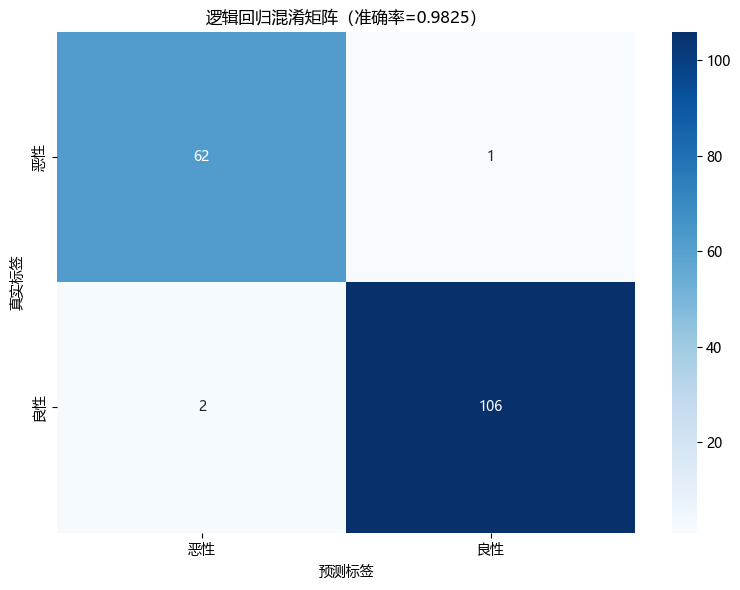

混淆矩阵解读：
左上：真恶性预测恶性（对）；右上：真恶性预测良性（错）
左下：真良性预测恶性（错）；右下：真良性预测良性（对）


In [5]:
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
lr_classifier.fit(X_c_train, y_c_train)
print("逻辑回归训练完成")

y_c_pred = lr_classifier.predict(X_c_test)
acc = accuracy_score(y_c_test, y_c_pred)
print(f"准确率：{acc:.4f}")

cm = confusion_matrix(y_c_test, y_c_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["恶性", "良性"],
    yticklabels=["恶性", "良性"],
)
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.title(f"逻辑回归混淆矩阵（准确率={acc:.4f}）")
plt.tight_layout()
plt.show()

print("混淆矩阵解读：")
print("左上：真恶性预测恶性（对）；右上：真恶性预测良性（错）")
print("左下：真良性预测恶性（错）；右下：真良性预测良性（对）")